In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn import metrics
from sklearn import ensemble
import seaborn as sns
from openpyxl import *
import statsmodels.api as sm
import rasterio
import joblib

In [3]:
def add_predictors(df):
        print('number of points:', len(df))
#         print('columns:', df.columns)
        print('agb summary:', df.AGB.describe())     
        

        df['Landsat_NDVI'] = (df['Landsat_NIR']-df['Landsat_Red'])/(df['Landsat_NIR']+df['Landsat_Red'])
        df['Landsat_GNDVI'] = (df['Landsat_NIR']-df['Landsat_Green'])/(df['Landsat_NIR']+df['Landsat_Green'])
        df['Landsat_EVI'] = 2.5*(df['Landsat_NIR']-df['Landsat_Red'])/(1+df['Landsat_NIR']+df['Landsat_Red']*6 -df['Landsat_Blue']*7.5)

        print('points after slope filter:', len(df))
        

        return df



In [4]:
def RF(X_train, y_train, band_to_use):
    param_distributions = {'n_estimators': [int(x) for x in np.linspace(start = 5, stop = 300, num = 50)],
                             'max_depth': [int(x) for x in np.linspace(3, 10, num = 8)], 
                           'max_features': ['sqrt', None],  
#                            'min_samples_split': [1, 2, 3, 4, 5],
#                            'min_samples_leaf': [1, 2, 3, 4, 5],
#                            'random_state':42,
                           'bootstrap': [True, False]
                          }

    # now create a searchCV object and fit it to the data
    search = RandomizedSearchCV(estimator=RandomForestRegressor(),
                                n_iter = 100, cv = 10, verbose=0, n_jobs = -1,
                                param_distributions=param_distributions,
                                random_state=522)
    

    search.fit(X_train, y_train)
    print('best params ',search.best_params_)
    return search

# Create evalutaion matrix
def evaluate(model, test_features, test_labels, band_to_use):
    
    test_features = test_features[band_to_use]
    predictions = model.predict(test_features)
#     print('pred., max: ', np.max(predictions), 'min: ', np.min(predictions))
#     print('\n')
#     print('predictions\n', predictions)
#     print('test_labels\n', test_labels)
    errors = abs(predictions - test_labels)
    mape = 100 * np.mean(errors / test_labels)
    accuracy = 100 - mape
    score_test = model.score(test_features, test_labels)
    rmse = np.sqrt(metrics.mean_squared_error(test_labels, predictions))
    nrmse = rmse/np.mean(test_labels)

    return np.mean(errors), mape, accuracy, score_test, rmse, nrmse

In [9]:
df = pd.read_csv('C:/Users/Asus/OneDrive/Documents/Act/UQ/FF/DEev/paper productivity/Data/training_july_2025.csv') 

df0 = df.drop(columns = ['unique_id_combined','unique_id_Avitabile', 'Year(s)_Avitabile',	'Year_ini_even',	
                         'Year_end_even',	'Year_mean_Avitabile',	'unique_id_GEDI',])
                        #'ysc_rc_deg', 'ysc_rc_def', 'ysc_ft_deg', 'ysc_ft_def'])

# 2. add predictors
df0 = add_predictors(df0)

# 3. use percentile
percentile = 100
df0 = df0[df0.AGB<=np.percentile(df0.AGB, percentile)]

df0 = df0[df0.fcd_average_period > 10 ]
df0 = df0[df0.Landsat_Green > 0 ]

# 4. train, test split
band_to_use = [s for s in df0.columns if 'wc' not in s]  # remove worldclim
band_to_use = [s for s in band_to_use if 's2' not in s]  # remove s2
band_to_use = [s for s in band_to_use if 'alos' not in s]  # remove s2
band_to_use = [s for s in band_to_use if 's1' not in s]  # remove s1
band_to_use = [s for s in band_to_use if 'FCD_20' not in s]  # remove s1

# band_to_use.remove('slope')
band_to_use.remove('AGB')


X0, y0 = df0[band_to_use], df['AGB']
X0 = X0.dropna()
y0 = y0[X0.index]
print('points after dropping na:', len(X0))
print('predictors:', band_to_use)

X_train0, X_test0, y_train0, y_test0 = train_test_split(X0, y0, test_size=0.20, random_state = 8845)   

# 5. train the model

search = RF(X_train0, y_train0, band_to_use)
print('Evaluate best model:')

print('on test data:')
errors_test, mape_test, accuracy_test, score_test, rmse_test, nrmse_test = evaluate(search.best_estimator_, X_test0, y_test0, band_to_use)
print('on train data:')
errors_train, mape_train, accuracy_train, score_train, rmse_train, nrmse_train = evaluate(search.best_estimator_, X_train0, y_train0, band_to_use)

data0 = pd.DataFrame({'Mae_test': errors_test, 'Mape_test': mape_test, 'Accuracy_test': [accuracy_test], 'Score_test': [score_test], 'Rmse_test': [rmse_test], 'Nrmse_test': [nrmse_test], 
    'Mae_train': errors_train, 'Mape_train': mape_train, 'Accuracy_train': [accuracy_train], 'Score_train': [score_train], 'Rmse_train': [rmse_train], 'Nrmse_train': [nrmse_train]})
print(data0)


number of points: 954
agb summary: count    954.000000
mean     156.432044
std       76.483789
min       11.830000
25%      115.715000
50%      153.000000
75%      208.922500
max      497.450000
Name: AGB, dtype: float64
points after slope filter: 954
points after dropping na: 909
predictors: ['x', 'y', 'Year_mean_even', 'elevation', 'fcd_average_period', 'ysc_rc_deg', 'ysc_rc_def', 'ysc_ft_deg', 'ysc_ft_def', 'Landsat_Blue', 'Landsat_Green', 'Landsat_Red', 'Landsat_NIR', 'Landsat_SWIR1', 'Landsat_SWIR2', 'HH_mean', 'Landsat_NDVI', 'Landsat_GNDVI', 'Landsat_EVI']
best params  {'n_estimators': 287, 'max_features': None, 'max_depth': 9, 'bootstrap': True}
Evaluate best model:
on test data:
on train data:
    Mae_test  Mape_test  Accuracy_test  Score_test  Rmse_test  Nrmse_test  \
0  22.660378  19.941677      80.058323     0.82316  33.528953    0.213395   

   Mae_train  Mape_train  Accuracy_train  Score_train  Rmse_train  Nrmse_train  
0   14.31671   11.365174       88.634826     0.92452

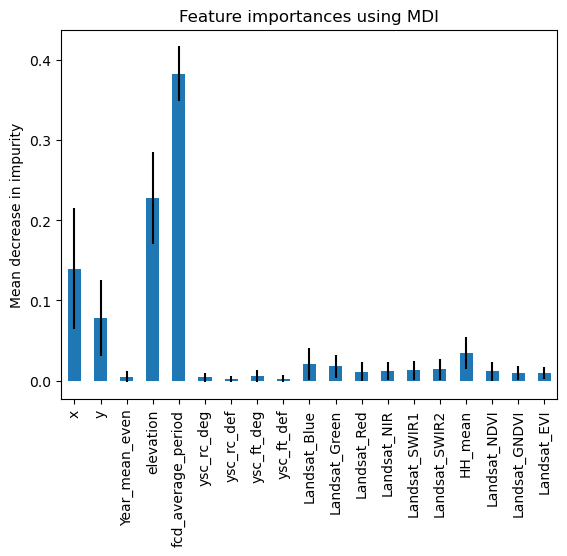

In [10]:
# Feature importance by Mean Decrease in Impurity
importances = search.best_estimator_.feature_importances_
std = np.std([tree.feature_importances_ for tree in search.best_estimator_], axis=0)
feature_names = band_to_use
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
plt.show()

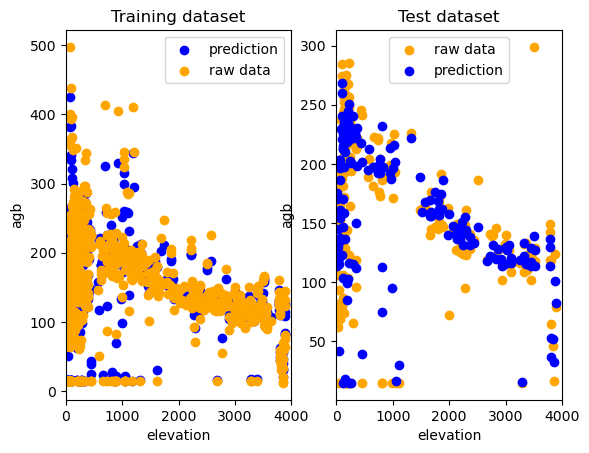

In [15]:
plt.subplot(1, 2, 1)
plt.scatter(X_train0.elevation, search.best_estimator_.predict(X_train0[band_to_use]), color = 'blue', label = 'prediction')
plt.scatter(X_train0.elevation, y_train0, color = 'orange', label = 'raw data')
plt.xlabel('elevation')
plt.ylabel('agb')
plt.title('Training dataset')
plt.xlim(0,4000)
plt.legend()
# plt.show()

plt.subplot(1, 2, 2)
plt.scatter(X_test0.elevation, y_test0, color = 'orange', label = 'raw data')
plt.scatter(X_test0.elevation, search.best_estimator_.predict(X_test0[band_to_use]), color = 'blue', label = 'prediction')
plt.xlabel('elevation')
plt.ylabel('agb')
plt.title('Test dataset')
plt.xlim(0,4000)
plt.legend()
plt.show()